In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

df = pd.read_csv("Global_Air_Pollution_Data_2025_2026.csv")

df = df.dropna()

In [ ]:
# QUAIS CIDADES TEM MAIOR POLUICAO?


TOP 10 CIDADES COM MAIOR PM2.5
City
Lahore, Pakistan      127.538919
Delhi, India          118.999038
Beijing, China        116.347665
Dhaka, Bangladesh      75.659020
Jakarta, Indonesia     51.582921
Sao Paulo, Brazil      16.986859
New York, USA          13.232921
London, UK              8.137546
Name: PM2.5, dtype: float64


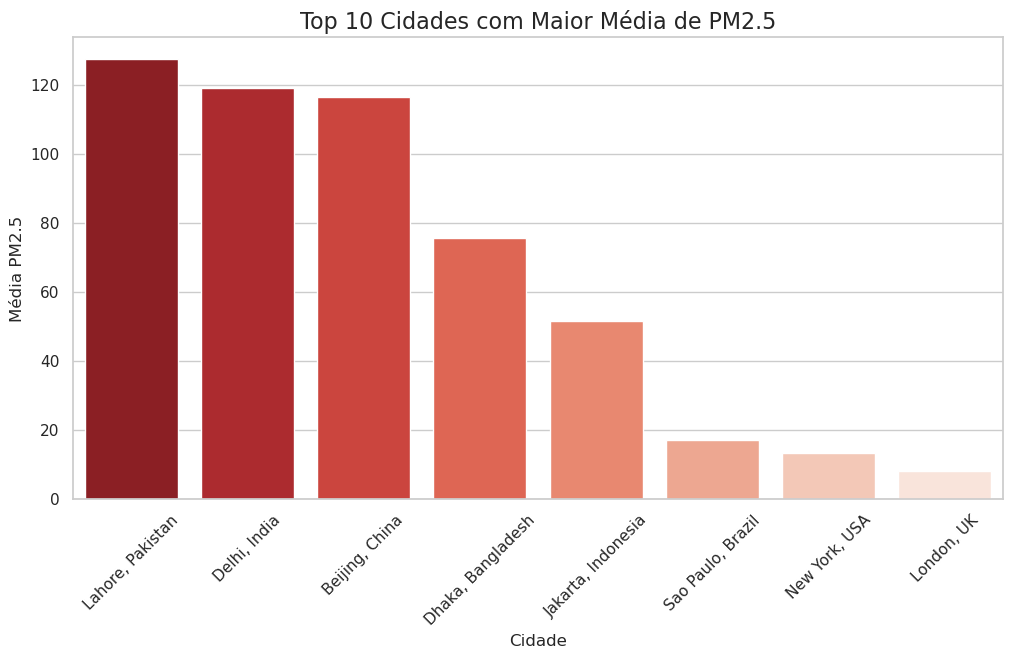

In [36]:
top_pm25 = (
    df.groupby("City")["PM2.5"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTOP 10 CIDADES COM MAIOR PM2.5")
print(top_pm25)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_pm25.reset_index(),
    x="City",
    y="PM2.5",
    hue="City",
    palette="Reds_r",
    legend=False
)

plt.title("Top 10 Cidades com Maior Média de PM2.5", fontsize=16)
plt.xlabel("Cidade")
plt.ylabel("Média PM2.5")

plt.xticks(rotation=45)

plt.show()

In [ ]:
# QUAL POLUENTE POSSUI MAIOR CONCENTRACAO MEDIA?


MEDIA DOS POLUENTES
CO       1264.659741
PM10       69.263124
PM2.5      66.060611
Ozone      54.746337
NO2        38.458871
SO2        30.292691
dtype: float64


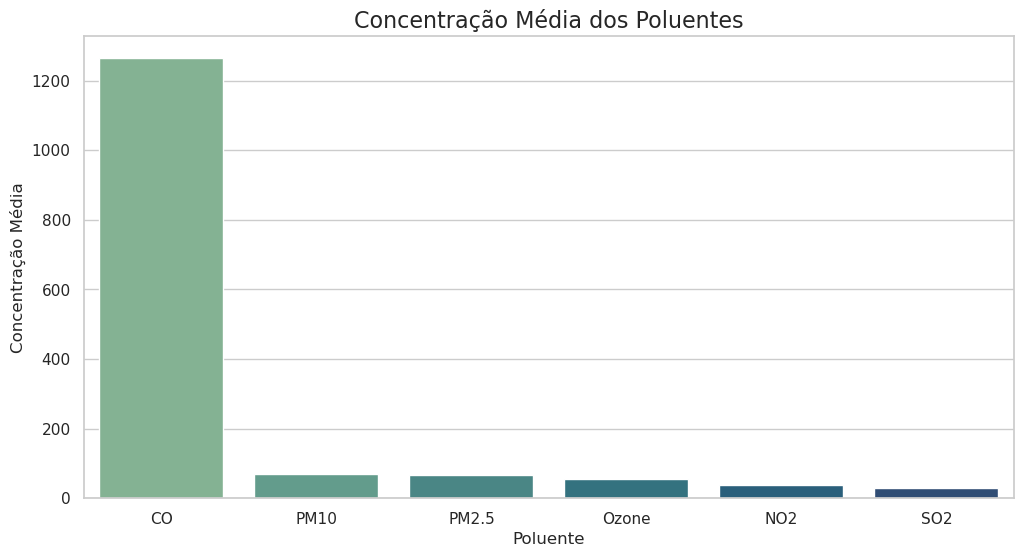

In [37]:
pollutants = [
    "PM2.5",
    "PM10",
    "NO2",
    "SO2",
    "CO",
    "Ozone"
]

pollution_means = (
    df[pollutants]
    .mean()
    .sort_values(ascending=False)
)

print("\nMEDIA DOS POLUENTES")
print(pollution_means)

plt.figure(figsize=(12,6))

sns.barplot(
    x=pollution_means.index,
    y=pollution_means.values,
    hue=pollution_means.index,
    palette="crest",
    legend=False
)

plt.title("Concentração Média dos Poluentes", fontsize=16)
plt.xlabel("Poluente")
plt.ylabel("Concentração Média")

plt.show()

In [ ]:
# RELACAO ENTRE PM2.5 E RISCO A SAUDE

<StringArray>
['Unhealthy', 'Unhealthy for Sensitive', 'Moderate', 'Hazardous', 'Good']
Length: 5, dtype: str
AQI_Class
Hazardous                  205.605123
Unhealthy                   94.158191
Unhealthy for Sensitive     45.042182
Moderate                    21.042283
Good                         6.903844
Name: PM2.5, dtype: float64


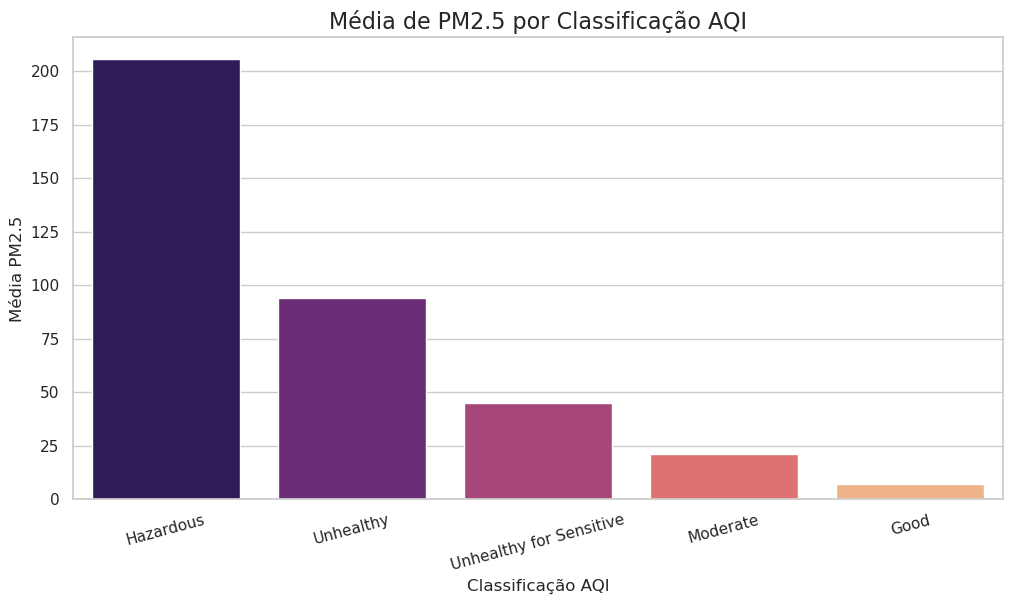

In [38]:
print(df["AQI_Class"].unique())

aqi_analysis = (
    df.groupby("AQI_Class")["PM2.5"]
    .mean()
    .sort_values(ascending=False)
)

print(aqi_analysis)

plt.figure(figsize=(12,6))

sns.barplot(
    data=aqi_analysis.reset_index(),
    x="AQI_Class",
    y="PM2.5",
    hue="AQI_Class",
    palette="magma",
    legend=False
)

plt.title("Média de PM2.5 por Classificação AQI", fontsize=16)
plt.xlabel("Classificação AQI")
plt.ylabel("Média PM2.5")

plt.xticks(rotation=15)

plt.show()

In [ ]:
# QUAL EPOCA POSSUI MAIOR POLUICAO?


MEDIA DE PM2.5 POR MES
Month
1     70.234375
2     61.048351
11    59.401630
12    67.797497
Name: PM2.5, dtype: float64


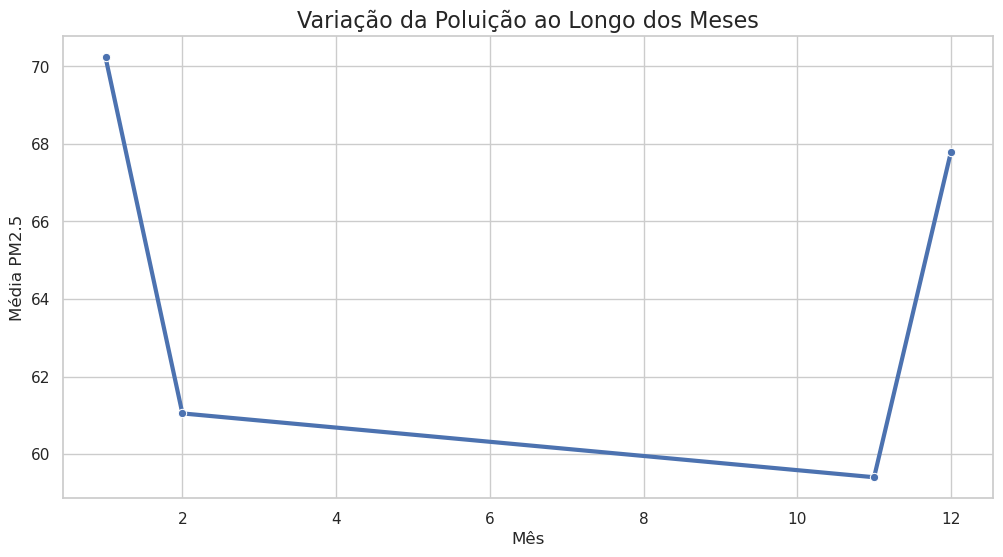

In [42]:
df["Date"] = pd.to_datetime(df["Date"])

df["Month"] = df["Date"].dt.month

monthly_pollution = (
    df.groupby("Month")["PM2.5"]
    .mean()
)

print("\nMEDIA DE PM2.5 POR MES")
print(monthly_pollution)

plt.figure(figsize=(12,6))

sns.lineplot(
    x=monthly_pollution.index,
    y=monthly_pollution.values,
    marker="o",
    linewidth=3
)

plt.title("Variação da Poluição ao Longo dos Meses", fontsize=16)
plt.xlabel("Mês")
plt.ylabel("Média PM2.5")

plt.show()

In [31]:
# QUAIS PAISES TIVERAM MELHORA OU PIORA?

      Country  Year       PM2.5
0  Bangladesh  2025   66.995988
1  Bangladesh  2026   88.302365
2      Brazil  2025   18.093056
3      Brazil  2026   15.372410
4       China  2025  118.474228


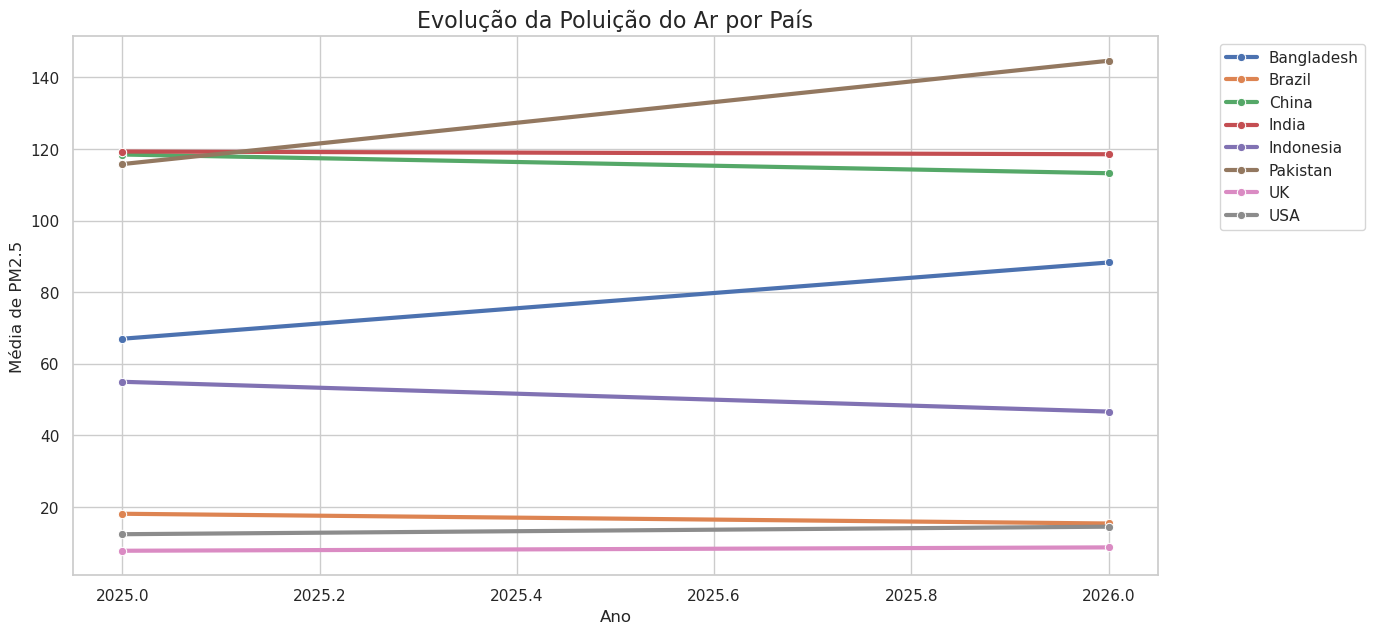


PAISES COM MAIOR PIORA
Year              2025        2026  Diferença
Country                                      
Pakistan    115.799151  144.672635  28.873484
Bangladesh   66.995988   88.302365  21.306377
USA          12.376852   14.482320   2.105468
UK            7.756096    8.694257   0.938161
India       119.307562  118.548761  -0.758800

PAISES COM MAIOR MELHORA
Year             2025        2026  Diferença
Country                                     
UK           7.756096    8.694257   0.938161
India      119.307562  118.548761  -0.758800
Brazil      18.093056   15.372410  -2.720646
China      118.474228  113.244032  -5.230197
Indonesia   54.968904   46.641216  -8.327688


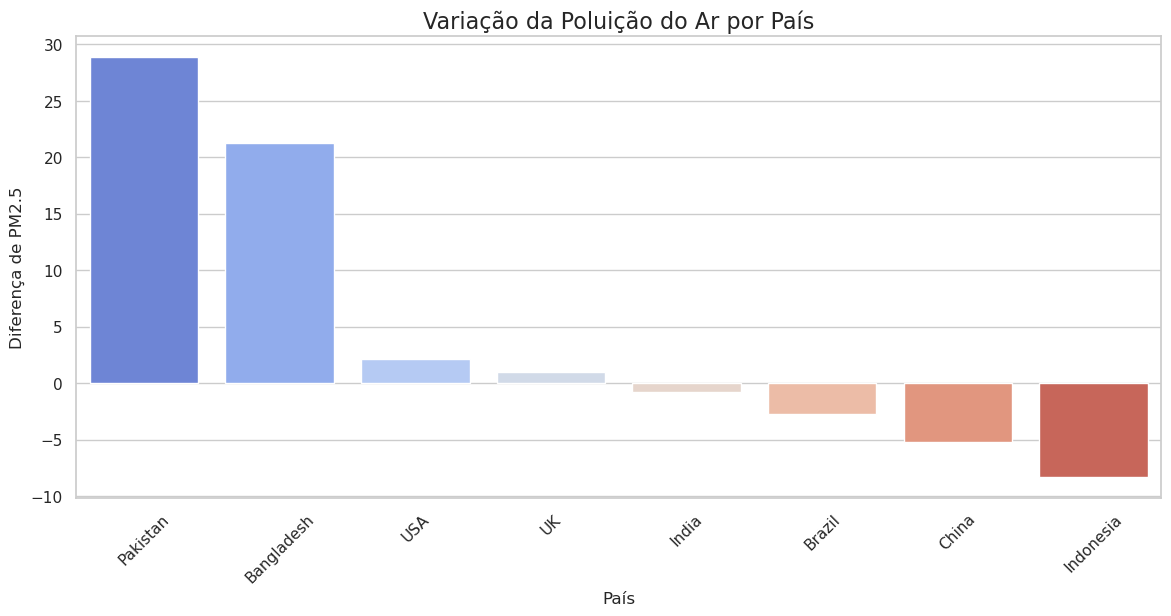

In [44]:
df["Date"] = pd.to_datetime(df["Date"])

# EXTRAIR ANO
df["Year"] = df["Date"].dt.year

df[["City_Name", "Country"]] = df["City"].str.split(",", expand=True)

# REMOVER ESPACOS
df["Country"] = df["Country"].str.strip()

pollution_trend = (
    df.groupby(["Country", "Year"])["PM2.5"]
    .mean()
    .reset_index()
)

print(pollution_trend.head())

plt.figure(figsize=(14,7))

sns.lineplot(
    data=pollution_trend,
    x="Year",
    y="PM2.5",
    hue="Country",
    marker="o",
    linewidth=3
)

plt.title("Evolução da Poluição do Ar por País", fontsize=16)
plt.xlabel("Ano")
plt.ylabel("Média de PM2.5")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.show()

trend_analysis = pollution_trend.pivot(
    index="Country",
    columns="Year",
    values="PM2.5"
)

trend_analysis["Diferença"] = (
    trend_analysis.iloc[:, -1] -
    trend_analysis.iloc[:, 0]
)

trend_analysis = trend_analysis.sort_values(
    by="Diferença",
    ascending=False
)

print("\nPAISES COM MAIOR PIORA")
print(trend_analysis.head())

print("\nPAISES COM MAIOR MELHORA")
print(trend_analysis.tail())

plt.figure(figsize=(14,6))

sns.barplot(
    data=trend_analysis.reset_index(),
    x="Country",
    y="Diferença",
    hue="Country",
    palette="coolwarm",
    legend=False
)

plt.title("Variação da Poluição do Ar por País", fontsize=16)
plt.xlabel("País")
plt.ylabel("Diferença de PM2.5")

plt.xticks(rotation=45)

plt.show()